# 02 — Train Emulators (Multi-z): GSMF, HMF, fGas, Pk-ratio

Multi-snapshot emulators with redshift interpolation support.
All models saved to `../models/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os

from cosmo_hydro_emu.pca import *
from cosmo_hydro_emu.viz import *
from cosmo_hydro_emu.load_hacc import *
from cosmo_hydro_emu.emu import *
from cosmo_hydro_emu.gp import *
from cosmo_hydro_emu.snapshot_utils import SNAPSHOT_IDS, get_snapshot_redshifts

## Configuration

In [ ]:
DirIn = '../data/400MPC_RUNS_5SG_2COSMO_PARAM/HAvoCC/'
DirIn_pk = '../data/scidac-olcf-pk_3/'

start_sim_idx = 1
num_sims = 39
# Training-time PCA budget. Inference auto-syncs basis size from the saved
# pickle (via load_model_autosync), so this value is not constrained by the
# Inference YAML's exp_variance — pick whatever gives the best emulator.
exp_variance = 0.999

z_initial = 200

seed_mass_scale = 1e6
vkin_scale = 1e4
eps_scale = 1e1

do_train = True

## Load parameters

In [3]:
fileIn = '../data/FinalDesign.txt'
params_all = np.loadtxt(fileIn, delimiter=",", skiprows=1)
# Design CSV row K corresponds to RUN_K (both 0-indexed); row 0 = RUN000.
# When loaders use start_sim_idx=1, num_sims=39 they read RUN001..RUN039, so
# the matching slice is rows [1:40] = [start_sim_idx : start_sim_idx + num_sims].
params32 = params_all[start_sim_idx : start_sim_idx + num_sims]

params32[:, 2] = params32[:, 2] / seed_mass_scale
params32[:, 3] = params32[:, 3] / vkin_scale
params32[:, 4] = params32[:, 4] / eps_scale

print('params32 shape:', params32.shape)

params32 shape: (39, 7)


## Train/test split

In [4]:
test_sim_indices = [3, 11, 19, 27, 35]
train_sim_indices = [i for i in range(num_sims) if i not in test_sim_indices]

params_train = params32[train_sim_indices]
params_test = params32[test_sim_indices]

print(f'Train: {len(train_sim_indices)} sims, Test: {len(test_sim_indices)} sims')

Train: 34 sims, Test: 5 sims


## Snapshot setup

In [5]:
z_all, a_all = get_snapshot_redshifts(SNAPSHOT_IDS, z_initial=z_initial)

print(f'{len(SNAPSHOT_IDS)} snapshots, z range: [{z_all.min():.3f}, {z_all.max():.3f}]')
print()
for i, (sid, z, a) in enumerate(zip(SNAPSHOT_IDS, z_all, a_all)):
    print(f'  [{i:2d}] snap {sid:3d}  z = {z:.4f}  a = {a:.4f}')

11 snapshots, z range: [0.000, 2.004]

  [ 0] snap 205  z = 2.0036  a = 0.3329
  [ 1] snap 224  z = 1.7534  a = 0.3632
  [ 2] snap 247  z = 1.5012  a = 0.3998
  [ 3] snap 275  z = 1.2503  a = 0.4444
  [ 4] snap 310  z = 0.9996  a = 0.5001
  [ 5] snap 355  z = 0.7490  a = 0.5717
  [ 6] snap 415  z = 0.4987  a = 0.6673
  [ 7] snap 479  z = 0.3001  a = 0.7692
  [ 8] snap 498  z = 0.2509  a = 0.7994
  [ 9] snap 567  z = 0.0998  a = 0.9093
  [10] snap 624  z = 0.0000  a = 1.0000


## GSMF — Galaxy Stellar Mass Function (11 snapshots)

In [6]:
# Load multi-snapshot GSMF data
stellar_mass, gsmf_arr = read_gsmf_all_snaps(DirIn, num_sims, SNAPSHOT_IDS, start_sim_idx=start_sim_idx)
print('stellar_mass shape:', stellar_mass.shape)
print('gsmf_arr shape:', gsmf_arr.shape)

# Mass cut
mlim1, mlim2 = mass_conds('GSMF')
mass_cond = np.where((stellar_mass > mlim1) & (stellar_mass < mlim2))[0]

# NaN interpolation per snapshot
for s in range(gsmf_arr.shape[1]):
    gsmf_arr[:, s, :] = fill_nan_with_interpolation(gsmf_arr[:, s, :], 'linear')

gsmf_y_vals = 10**gsmf_arr[:, :, mass_cond]  # shape (39, 11, n_bins)
gsmf_y_ind = stellar_mass[mass_cond]
print('gsmf_y_vals shape:', gsmf_y_vals.shape, '  gsmf_y_ind shape:', gsmf_y_ind.shape)

stellar_mass shape: (39,)
gsmf_arr shape: (39, 11, 39)
gsmf_y_vals shape: (39, 11, 16)   gsmf_y_ind shape: (16,)


In [7]:
# Train / load GSMF multi-z emulators
model_dir = '../models/GSMF_multiz/'
z_index_range = np.arange(len(SNAPSHOT_IDS))  # all 11 snapshots

if do_train:
    os.makedirs(model_dir, exist_ok=True)
    from cosmo_hydro_emu.gp import do_gp_train_multiple
    do_gp_train_multiple(
        model_dir=model_dir,
        p_train_all=params_train,
        y_vals_all=gsmf_y_vals[train_sim_indices],
        y_ind_all=gsmf_y_ind,
        z_index_range=z_index_range,
        exp_variance=exp_variance
    )

# Load all snapshot models
gsmf_model_list, gsmf_data_list = load_model_multiple(
    model_dir=model_dir,
    p_train_all=params_train,
    y_vals_all=gsmf_y_vals[train_sim_indices],
    y_ind_all=gsmf_y_ind,
    z_index_range=z_index_range,
)
print(f'Loaded {len(gsmf_model_list)} GSMF models')

Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]
lamUz
[[5. 5. 5.]]
lamWs
[[100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:14<00:00,  3.37it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[6.01181190e-01 4.09973652e-01 2.14565223e-01]
 [1.39538105e-01 6.46998200e-01 1.79052935e+00]
 [3.26315978e-01 1.03719631e+00 1.09935011e+00]
 [4.16115764e-03 3.86884214e-01 1.59573474e+00]
 [2.32829036e-03 1.15404856e-02 4.13594779e-02]
 [6.69938823e-04 1.72031710e-02 3.16931341e-02]
 [3.19088913e-02 1.83468847e-01 7.90602531e-02]
 [1.00284581e-01 3.52837639e-01 7.80916498e-01]]
lamUz
[[1.36000458 1.45205319 1.60115143]]
lamWs
[[4547.76667316 4770.95577924 5111.72253617]]
lamWOs
[[1003.71136652]]


MCMC sampling: 100%|██████████| 1000/1000 [00:12<00:00, 79.16it/s]


Model saved to ../models/GSMF_multiz/multivariate_model_z_index0.pkl
Training complete for snapshot 0
Model saved at ../models/GSMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]
lamUz
[[5. 5. 5.]]
lamWs
[[100. 100. 100.]]
lamWOs
[[100.]]


...

Model saved to ../models/GSMF_multiz/multivariate_model_z_index9.pkl
Training complete for snapshot 9
Model saved at ../models/GSMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:21<00:00,  2.30it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[5.06779442e-01 5.71939944e-01 2.24845460e-01 5.98297876e-01
  5.64572562e-01]
 [2.49295369e-01 5.55536568e-01 1.39159211e+00 3.32982919e+00
  2.67914684e+00]
 [5.39050213e-01 4.27663330e-01 8.11181929e-01 2.96103889e+00
  4.66415096e-01]
 [4.66382491e-03 7.98887624e-01 3.16573573e+00 5.73136649e+00
  1.80633944e+00]
 [3.17694846e-03 1.09663442e-02 2.04869910e-02 4.98908383e-02
  1.34736194e-01]
 [8.11386092e-03 1.26731827e-01 5.49446408e-01 1.86873535e+00
  2.69072560e+00]
 [6.51364958e-02 3.11733704e-02 7.31456893e-02 1.70357877e-01
  3.32611428e-01]
 [8.49441182e-02 1.00500104e-01 7.43901715e-02 6.04125301e-01
  3.73262874e+00]]
lamUz
[[1.63334905 1.35278478 1.35105577 1.69562098 1.94803293]]
lamWs
[[4268.10295183 3955.11406284 4648.85319809 4521.07845709 4611.51670315]]
lamWOs
[[621.90822294]]


MCMC sampling: 100%|██████████| 1000/1000 [00:19<00:00, 52.49it/s]


Model saved to ../models/GSMF_multiz/multivariate_model_z_index10.pkl
Training complete for snapshot 10
Model saved at ../models/GSMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Number of models loaded: 11 from: ../models/GSMF_multiz/
Loaded 11 GSMF models
Maximum relative error (mean): 0.0047 (0.47%)
Mean relative error (mean): 0.0015 (0.15%)
Maximum relative error (quantiles): 0.0156 (1.56%)
Mean relative error (quantiles): 0.0074 (0.74%)
0.9974874192679752 1.0503929277869744
halo_mass shape: (49,)
hmf_arr shape: (39, 11, 49)
hmf_y_vals shape: (39, 11, 30)   hmf_y_ind shape: (30,)
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]]
lamUz
[[5. 5.]]
lamWs
[[100. 100.]]
lamWOs
[[100.]]
Done with tune_step_size.
Selected step sizes:
betaU
[[0.73339966 0.29927195]
 [0.00219279 0.02324117]
 [0.00428722 0.05793873]
 [0.00098732 0.09400938]
 [0.00290082 0.01804537]
 [0.00102216

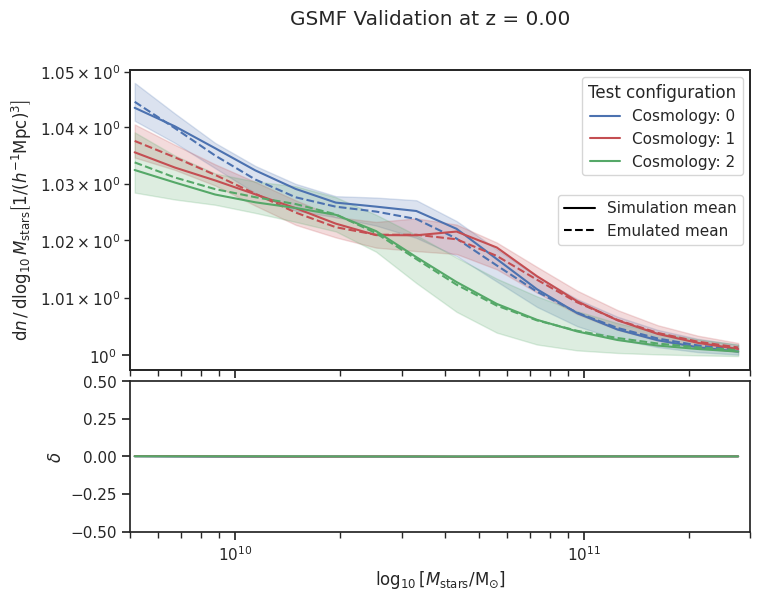

In [20]:
# GSMF validation at z=0 (last snapshot)
input_params = params_test[:3]
target_vals = gsmf_y_vals[test_sim_indices[:3], -1, :]

pred_mean, pred_quant = emulate(gsmf_model_list[-1], input_params)

plt_strings = plot_strings('GSMF')
validation_plot(gsmf_y_ind, target_vals, pred_mean, pred_quant,
                *plt_strings, mlim1, mlim2, 'log', 'log');
plt.suptitle(f'GSMF Validation at z = {z_all[-1]:.2f}')
plt.savefig('../plots/GSMF_multiz_valid.png', bbox_inches='tight')

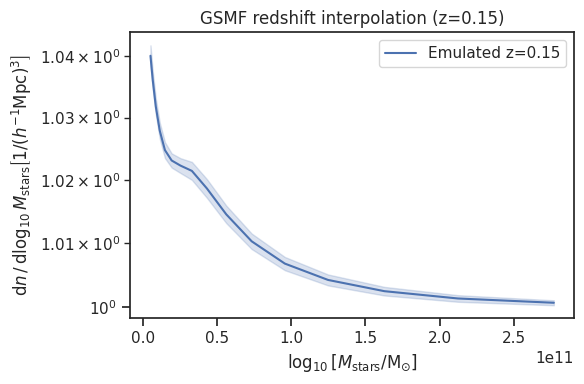

In [9]:
# GSMF redshift interpolation test
test_params = params32[test_sim_indices[0]]
params_with_z = np.append(test_params, [0.15])[np.newaxis, :]
pred_z, pred_z_err = emu_redshift(params_with_z, gsmf_model_list, gsmf_data_list, z_all)

plt.figure(figsize=(6, 4))
plt.plot(gsmf_y_ind, pred_z.flatten(), 'b-', label='Emulated z=0.15')
plt.fill_between(gsmf_y_ind,
                 pred_z.flatten() - pred_z_err.flatten(),
                 pred_z.flatten() + pred_z_err.flatten(),
                 alpha=0.2, color='b')
plt.xlabel(plot_strings('GSMF')[1])
plt.ylabel(plot_strings('GSMF')[2])
plt.yscale('log')
plt.title('GSMF redshift interpolation (z=0.15)')
plt.legend()
plt.tight_layout()

## HMF — Halo Mass Function (11 snapshots)

In [10]:
# Load multi-snapshot HMF data
halo_mass, hmf_arr = read_hmf_all_snaps(DirIn, num_sims, SNAPSHOT_IDS, start_sim_idx=start_sim_idx)
print('halo_mass shape:', halo_mass.shape)
print('hmf_arr shape:', hmf_arr.shape)

# Mass cut
mlim1_hmf, mlim2_hmf = mass_conds('HMF')
mass_cond_hmf = np.where((halo_mass > mlim1_hmf) & (halo_mass < mlim2_hmf))[0]

# NaN interpolation per snapshot
for s in range(hmf_arr.shape[1]):
    hmf_arr[:, s, :] = fill_nan_with_interpolation(hmf_arr[:, s, :], 'linear')

hmf_y_vals = 10**hmf_arr[:, :, mass_cond_hmf]
hmf_y_ind = halo_mass[mass_cond_hmf]
print('hmf_y_vals shape:', hmf_y_vals.shape, '  hmf_y_ind shape:', hmf_y_ind.shape)

In [11]:
# Train / load HMF multi-z emulators
model_dir_hmf = '../models/HMF_multiz/'
z_index_range_hmf = np.arange(len(SNAPSHOT_IDS))  # all 11 snapshots

if do_train:
    os.makedirs(model_dir_hmf, exist_ok=True)
    do_gp_train_multiple(
        model_dir=model_dir_hmf,
        p_train_all=params_train,
        y_vals_all=hmf_y_vals[train_sim_indices],
        y_ind_all=hmf_y_ind,
        z_index_range=z_index_range_hmf,
        exp_variance=exp_variance
    )

# Load all snapshot models
hmf_model_list, hmf_data_list = load_model_multiple(
    model_dir=model_dir_hmf,
    p_train_all=params_train,
    y_vals_all=hmf_y_vals[train_sim_indices],
    y_ind_all=hmf_y_ind,
    z_index_range=z_index_range_hmf,
)
print(f'Loaded {len(hmf_model_list)} HMF models')

MCMC sampling: 100%|██████████| 1000/1000 [00:19<00:00, 51.21it/s]


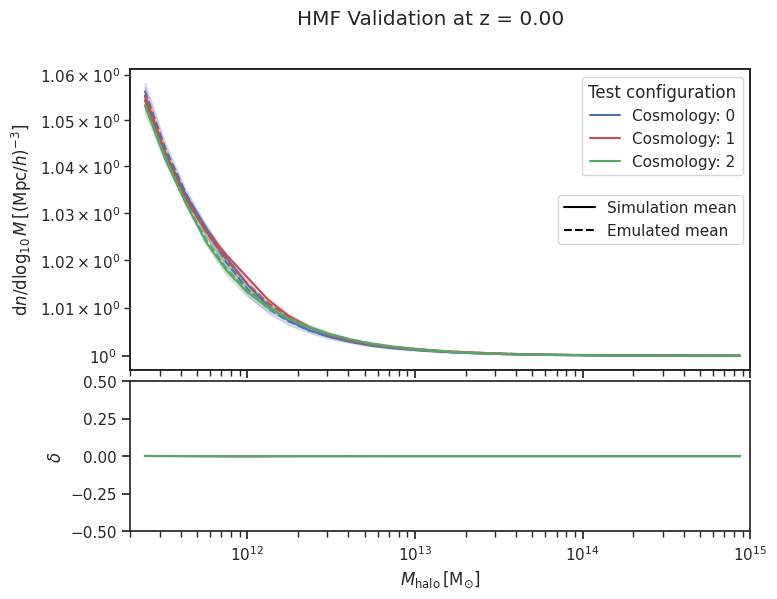

In [21]:
# HMF validation at z=0
input_params_hmf = params_test[:3]
target_vals_hmf = hmf_y_vals[test_sim_indices[:3], -1, :]

pred_mean_hmf, pred_quant_hmf = emulate(hmf_model_list[-1], input_params_hmf)

plt_strings_hmf = plot_strings('HMF')
validation_plot(hmf_y_ind, target_vals_hmf, pred_mean_hmf, pred_quant_hmf,
                *plt_strings_hmf, mlim1_hmf, mlim2_hmf, 'log', 'log');
plt.suptitle(f'HMF Validation at z = {z_all[-1]:.2f}')
plt.savefig('../plots/HMF_multiz_valid.png', bbox_inches='tight')

## fGas — Cluster Gas Fraction (7 snapshots, z ≤ 1.0)

In [13]:
# Load multi-snapshot fGas data
log_halo_mass, fgas_arr = read_gasfr_all_snaps(DirIn, num_sims, SNAPSHOT_IDS, start_sim_idx=start_sim_idx)
print('log_halo_mass shape:', log_halo_mass.shape)
print('fgas_arr shape:', fgas_arr.shape)

# Mass cut. mass_conds('fGas') returns linear mass limits (10**13.5, 10**14.3),
# while log_halo_mass is in log10 units — exponentiate before comparing.
mlim1_fg, mlim2_fg = mass_conds('fGas')
mass_cond_fg = np.where((10**log_halo_mass > mlim1_fg) & (10**log_halo_mass < mlim2_fg))[0]

# NaN interpolation per snapshot (cubic for fGas)
for s in range(fgas_arr.shape[1]):
    fgas_arr[:, s, :] = fill_nan_with_interpolation(fgas_arr[:, s, :], 'cubic')

fgas_y_vals = fgas_arr[:, :, mass_cond_fg]
fgas_y_ind = 10**log_halo_mass[mass_cond_fg]
print('fgas_y_vals shape:', fgas_y_vals.shape, '  fgas_y_ind shape:', fgas_y_ind.shape)

In [14]:
# Train / load fGas multi-z emulators (only snapshots 4-10, z <= 1.0)
model_dir_fg = '../models/fGas_multiz/'
z_index_range_fg = np.arange(4, 11)  # 7 valid snapshots

fgas_z_all = z_all[z_index_range_fg]
print(f'fGas valid snapshots: {len(z_index_range_fg)}, z range: [{fgas_z_all.min():.3f}, {fgas_z_all.max():.3f}]')

if do_train:
    os.makedirs(model_dir_fg, exist_ok=True)
    do_gp_train_multiple(
        model_dir=model_dir_fg,
        p_train_all=params_train,
        y_vals_all=fgas_y_vals[train_sim_indices],
        y_ind_all=fgas_y_ind,
        z_index_range=z_index_range_fg,
        exp_variance=exp_variance
    )

# Load all snapshot models
fgas_model_list, fgas_data_list = load_model_multiple(
    model_dir=model_dir_fg,
    p_train_all=params_train,
    y_vals_all=fgas_y_vals[train_sim_indices],
    y_ind_all=fgas_y_ind,
    z_index_range=z_index_range_fg,
)
print(f'Loaded {len(fgas_model_list)} fGas models')

MCMC sampling: 100%|██████████| 1000/1000 [00:11<00:00, 89.68it/s]


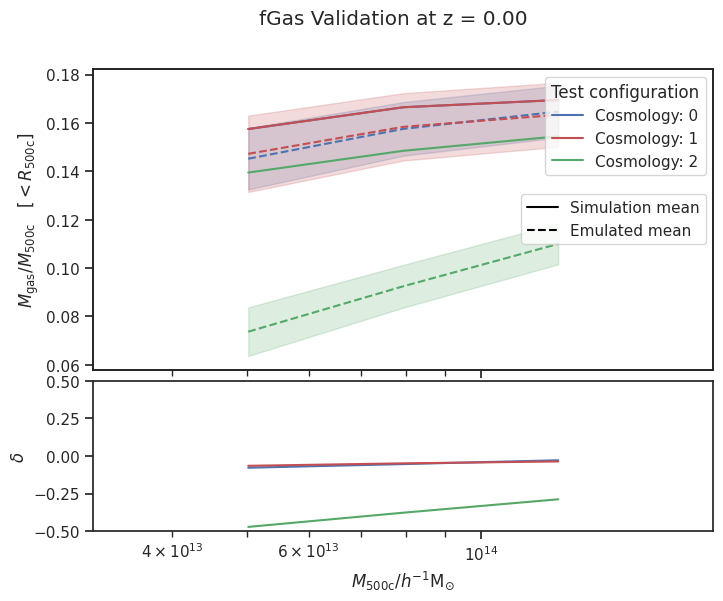

In [15]:
# fGas validation at z=0 (last snapshot in valid range)
input_params_fg = params_test[:3]
target_vals_fg = fgas_y_vals[test_sim_indices[:3], -1, :]

pred_mean_fg, pred_quant_fg = emulate(fgas_model_list[-1], input_params_fg)

plt_strings_fg = plot_strings('fGas')
validation_plot(fgas_y_ind, target_vals_fg, pred_mean_fg, pred_quant_fg,
                *plt_strings_fg, mlim1_fg, mlim2_fg, 'log', 'linear');
plt.suptitle(f'fGas Validation at z = {z_all[-1]:.2f}')
plt.savefig('../plots/fGas_multiz_valid.png', bbox_inches='tight')

## Pk — Power Spectrum Suppression (z=0 only)

In [16]:
# Load Pk data (z=0 only)
k, pk_arr, pk_go_arr, pk_ratio = read_pk_new(
    DirIn_pk, num_sims, redshift='0.0', pk_type='hydro.full', start_sim_idx=start_sim_idx
)
print('k shape:', k.shape)
print('pk_ratio shape:', pk_ratio.shape)

# k-range cut
mlim1_pk, mlim2_pk = mass_conds('Pk')
k_cond = np.where((k > mlim1_pk) & (k < mlim2_pk))[0]

pk_y_vals = pk_ratio[:, k_cond]
pk_y_ind = k[k_cond]
print('pk_y_vals shape:', pk_y_vals.shape, '  pk_y_ind shape:', pk_y_ind.shape)

Step size tuning:   0%|          | 0/50 [00:00<?, ?it/s]

MCMC sampling: 100%|██████████| 1000/1000 [00:03<00:00, 253.72it/s]


(None, <Figure size 1000x750 with 5 Axes>)

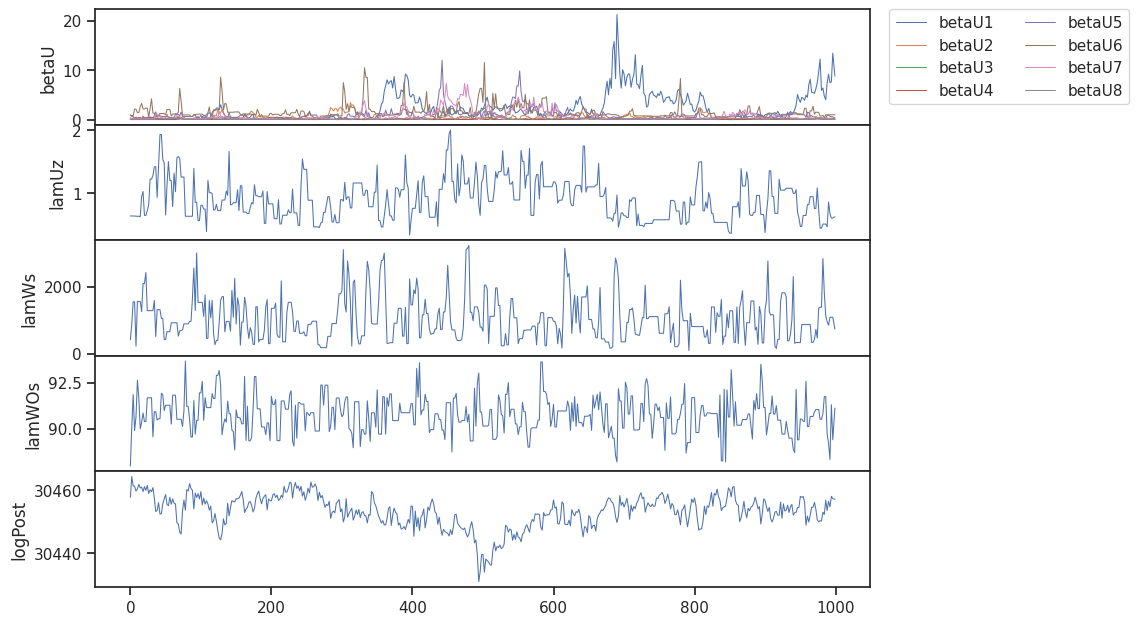

In [17]:
# Train / load Pk emulator (single z=0, exp_variance=0.95)
z_index = 0
model_filename_pk = '../models/Pk_multivariate_model_z_index' + str(z_index)

p_all_train_pk = params32[train_sim_indices]
pk_y_vals_train = pk_y_vals[train_sim_indices]

sepia_data_pk = sepia_data_format(p_all_train_pk, pk_y_vals_train, pk_y_ind)
sepia_model_pk = do_pca(sepia_data_pk, exp_variance=0.95)

if do_train:
    sepia_model_pk = do_gp_train(sepia_model_pk, model_filename_pk)

sepia_model_pk = gp_load(sepia_model_pk, model_filename_pk)
plot_train_diagnostics(sepia_model_pk)

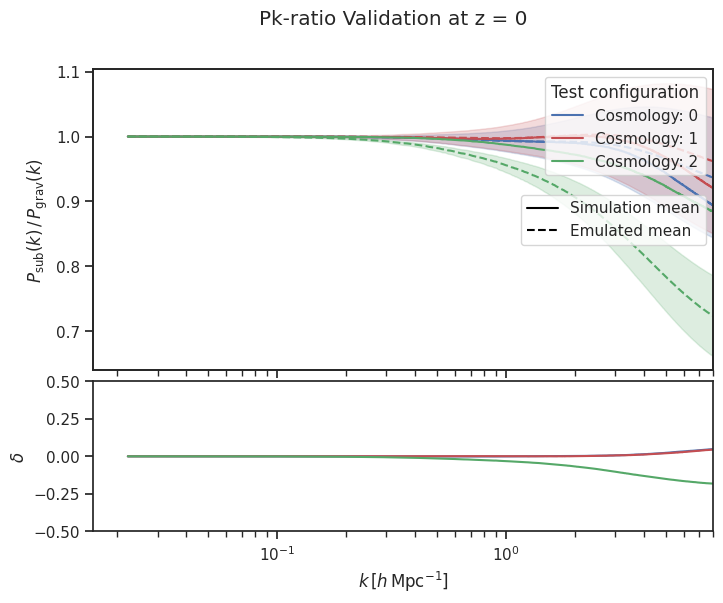

In [18]:
# Pk validation at z=0
input_params_pk = params_test[:3]
target_vals_pk = pk_y_vals[test_sim_indices[:3]]

pred_mean_pk, pred_quant_pk = emulate(sepia_model_pk, input_params_pk)

plt_strings_pk = plot_strings('Pk')
validation_plot(pk_y_ind, target_vals_pk, pred_mean_pk, pred_quant_pk,
                *plt_strings_pk, mlim1_pk, mlim2_pk, 'log', 'linear');
plt.suptitle('Pk-ratio Validation at z = 0')
plt.savefig('../plots/Pk_valid.png', bbox_inches='tight')

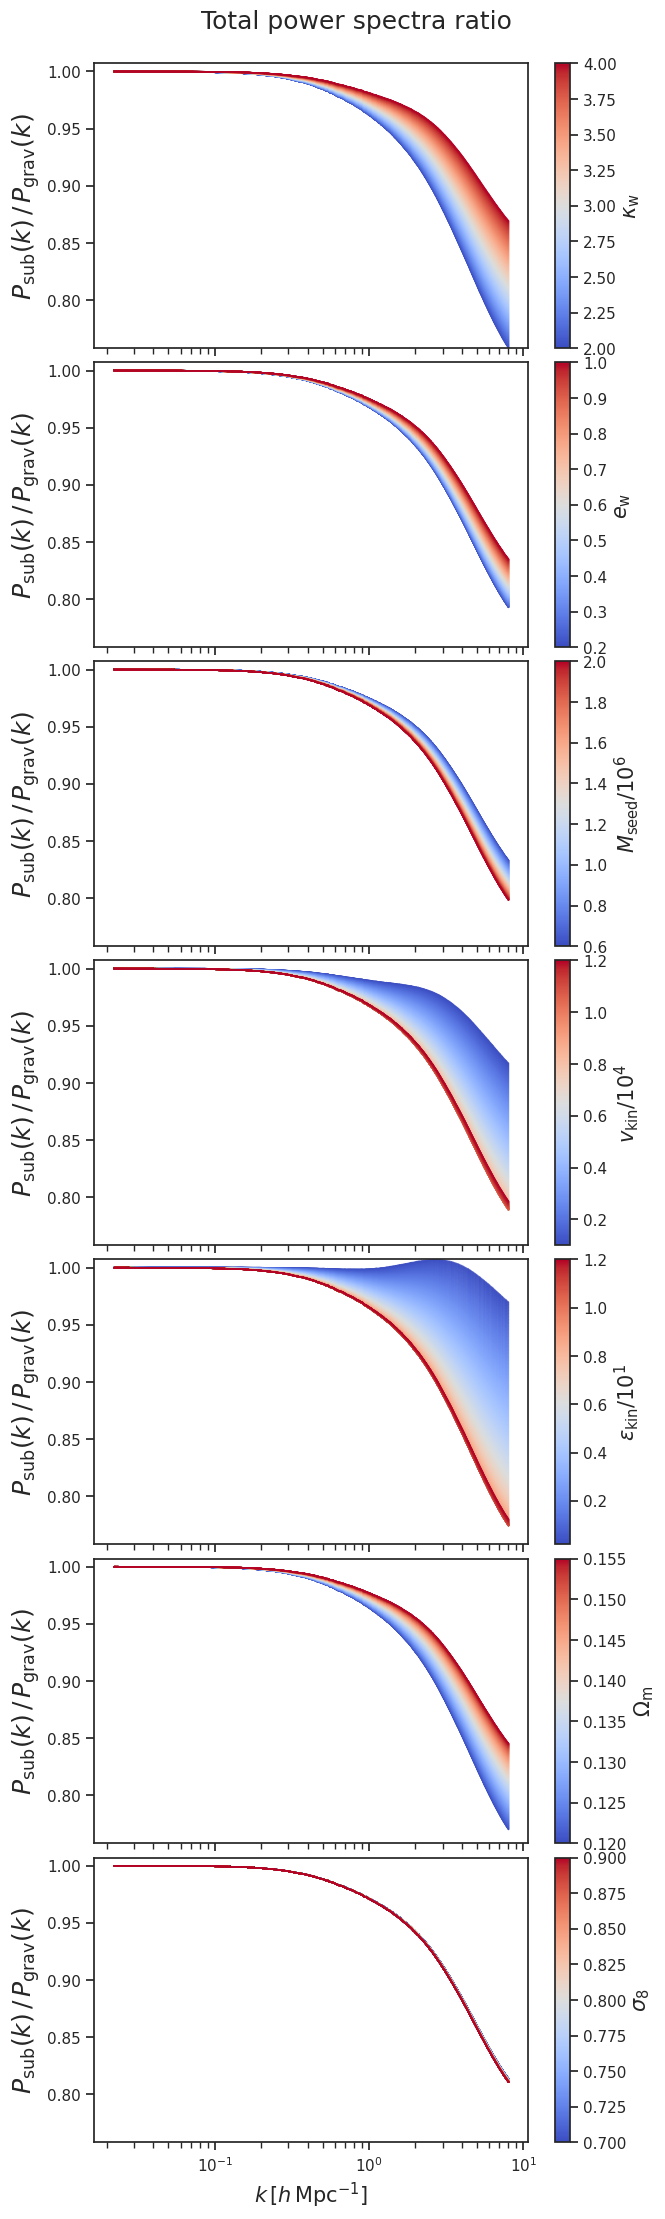

In [19]:
# Pk sensitivity
f = sensitivity_plot(pk_y_ind, params32, sepia_model_pk, emulate, PARAM_NAME,
                     *plt_strings_pk, mlim1_pk, mlim2_pk, 'log', 'linear')
plt.savefig('../plots/Pk_sensi.png', bbox_inches='tight')

## Extra summary plots (ported from `_old/gp_SGC_all_multiz.ipynb` and `_old/gp_SGC_pk.ipynb`)

In [ ]:
# exp_design.png  +  exp_design_pk.png — design-space scatter matrix
df_design = pd.DataFrame(params32, columns=PARAM_NAME)
plot_scatter_matrix(df_design, ['b'] * params32.shape[0]);
plt.savefig('../plots/exp_design.png', bbox_inches='tight')
plt.savefig('../plots/exp_design_pk.png', bbox_inches='tight')
plt.show()

# snapshot_z.png — redshift mapping of available snapshots
plt.figure(figsize=(8, 3))
plt.plot(SNAPSHOT_IDS, z_all, 'o-')
plt.xlabel('Snapshot ID'); plt.ylabel('Redshift z')
plt.title('Snapshot to Redshift Mapping')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/snapshot_z.png', bbox_inches='tight')
plt.show()

In [ ]:
# GSMF_multiz.png / HMF_multiz.png / fGas_multiz.png — sim ensemble at multiple z
import matplotlib.pyplot as plt

# --- GSMF ---
snap_indices_to_plot = [-1, -5, -10, 0]
plt_strings = plot_strings('GSMF')
mlim1, mlim2 = mass_conds('GSMF')
gsmf_mask = (stellar_mass > mlim1) & (stellar_mass < mlim2)
fig, axes = plt.subplots(1, len(snap_indices_to_plot),
                         figsize=(4*len(snap_indices_to_plot), 4), sharey=True)
for i, snap_idx in enumerate(snap_indices_to_plot):
    ax = axes[i]; z_snap = z_all[snap_idx]
    for sim_i in range(num_sims):
        ax.plot(stellar_mass[gsmf_mask], gsmf_y_vals[sim_i, snap_idx, :],
                'k-', alpha=0.15)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'z = {z_snap:.2f}'); ax.set_xlabel(plt_strings[1])
    if i == 0: ax.set_ylabel(plt_strings[2])
    ax.set_xlim(0.5*mlim1, 2*mlim2)
plt.suptitle('Galaxy Stellar Mass Function', y=1.02); plt.tight_layout()
plt.savefig('../plots/GSMF_multiz.png', bbox_inches='tight'); plt.show()

# --- HMF ---
plt_strings_hmf = plot_strings('HMF')
hmf_mask = (halo_mass > mlim1_hmf) & (halo_mass < mlim2_hmf)
fig, axes = plt.subplots(1, len(snap_indices_to_plot),
                         figsize=(4*len(snap_indices_to_plot), 4), sharey=True)
for i, snap_idx in enumerate(snap_indices_to_plot):
    ax = axes[i]; z_snap = z_all[snap_idx]
    for sim_i in range(num_sims):
        ax.plot(halo_mass[hmf_mask], hmf_y_vals[sim_i, snap_idx, :],
                'k-', alpha=0.15)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'z = {z_snap:.2f}'); ax.set_xlabel(plt_strings_hmf[1])
    if i == 0: ax.set_ylabel(plt_strings_hmf[2])
    ax.set_xlim(0.5*mlim1_hmf, 2*mlim2_hmf)
plt.suptitle('Halo Mass Function', y=1.02); plt.tight_layout()
plt.savefig('../plots/HMF_multiz.png', bbox_inches='tight'); plt.show()

# --- fGas ---
fgas_snap_indices = [-1, -5, -7, -10]
plt_strings_fgas = plot_strings('fGas')
fig, axes = plt.subplots(1, len(fgas_snap_indices),
                         figsize=(4*len(fgas_snap_indices), 4), sharey=True)
for i, snap_idx in enumerate(fgas_snap_indices):
    ax = axes[i]; z_snap = z_all[snap_idx]
    for sim_i in range(num_sims):
        ax.plot(fgas_y_ind, fgas_y_vals[sim_i, snap_idx, :], 'k-', alpha=0.15)
    ax.set_xscale('log')
    ax.set_title(f'z = {z_snap:.2f}'); ax.set_xlabel(plt_strings_fgas[1])
    if i == 0: ax.set_ylabel(plt_strings_fgas[2])
plt.suptitle('Cluster Gas Fraction', y=1.02); plt.tight_layout()
plt.savefig('../plots/fGas_multiz.png', bbox_inches='tight'); plt.show()